# 06_01 - Decision Engine: Heuristic Policy
## 1. Methodology Overview

This notebook builds the interpretable rule-based decision engine that consumes quantile forecasts and market inputs.
It follows the same project modules used by the pipeline so results are reproducible and consistent with backtesting.

**Source data used in this notebook:**
- `data/processed/train_features.csv`
- `data/processed/validation_features.csv`

**Core modules used in this notebook:**
- `src/models/train_model.py`
- `src/decision/policy_inputs.py`
- `src/decision/heuristic_policy.py`

In [1]:
from pathlib import Path
import sys

import pandas as pd
from IPython.display import display

project_root = Path.cwd().resolve()
if not (project_root / 'src').exists():
    project_root = Path('../../').resolve()
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

train_df = pd.read_csv(project_root / 'data/processed/train_features.csv')
validation_df = pd.read_csv(project_root / 'data/processed/validation_features.csv')

print(f'Train features: {train_df.shape[0]} rows x {train_df.shape[1]} columns')
print(f'Validation features: {validation_df.shape[0]} rows x {validation_df.shape[1]} columns')
display(validation_df.head())

Train features: 1461 rows x 155 columns
Validation features: 366 rows x 155 columns


,Date,Spot_Price_SPEL,Future_M1_Price,Future_M1_OpenInterest,Future_M2_Price,Future_M2_OpenInterest,Future_M3_Price,Future_M3_OpenInterest,Future_M4_Price,Future_M4_OpenInterest,...,future_m5_oi_change_1d,future_m5_oi_change_7d,future_m5_oi_pct_change_1d,future_m5_oi_pct_change_7d,future_m6_oi_change_1d,future_m6_oi_change_7d,future_m6_oi_pct_change_1d,future_m6_oi_pct_change_7d,front_month_premium,front_month_premium_rel
0,2024-01-01,36.24,76.50,365.0,75.25,355.0,66.00,354.0,57.26,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.26,1.110927
1,2024-01-02,40.91,74.25,355.0,63.50,354.0,55.75,0.0,56.85,0.0,...,0.0,NaN,NaN,NaN,0.0,NaN,NaN,NaN,33.34,0.814960
2,2024-01-03,55.08,76.50,355.0,67.00,354.0,57.29,0.0,58.38,0.0,...,0.0,NaN,NaN,NaN,0.0,NaN,NaN,NaN,21.42,0.388889
3,2024-01-04,91.36,77.00,365.0,68.00,354.0,57.36,0.0,61.50,0.0,...,0.0,NaN,NaN,NaN,0.0,NaN,NaN,NaN,-14.36,-0.157180
4,2024-01-05,68.62,77.50,365.0,69.20,354.0,59.36,0.0,63.50,0.0,...,0.0,NaN,NaN,NaN,0.0,NaN,NaN,NaN,8.88,0.129408


## 2. Build Policy Inputs and Apply the Heuristic Engine

We train the quantile suite, transform outputs into policy-ready inputs, and then apply the heuristic rules.
This mirrors the production flow used in the pipeline.

In [2]:
from src.models.train_model import train_quantile_suite
from src.decision.policy_inputs import prepare_policy_inputs, summarize_policy_inputs
from src.decision.heuristic_policy import apply_heuristic_policy, summarize_policy_actions

quantile_output = train_quantile_suite(train_df=train_df, eval_df=validation_df)
policy_inputs_df = prepare_policy_inputs(validation_df, quantile_output.results)
heuristic_policy_df = apply_heuristic_policy(policy_inputs_df)

print('Policy input overview:')
display(summarize_policy_inputs(policy_inputs_df))

print('Policy output preview:')
display(
    heuristic_policy_df[[
        'date',
        'forecast_central',
        'forecast_tail',
        'current_m1_future',
        'tail_vs_future_abs',
        'tail_vs_central_abs',
        'recommended_action',
        'decision_reason',
    ]].head(12)
)

Policy input overview:


,n_rows,date_min,date_max,n_quantile_columns,has_weekend_flag,has_holiday_flag,has_volume_column
0,337,2024-01-29,2024-12-30,3,True,False,False


Policy output preview:


,date,forecast_central,forecast_tail,current_m1_future,tail_vs_future_abs,tail_vs_central_abs,recommended_action,decision_reason
0,2024-01-29,80.235959,83.679672,60.26,23.419672,3.443712,buy_m1_future,Tail risk exceeds futures price threshold
1,2024-01-30,86.721442,84.432614,59.30,25.132614,-2.288828,buy_m1_future,Tail risk exceeds futures price threshold
2,2024-01-31,83.379503,84.115509,61.65,22.465509,0.736007,buy_m1_future,Tail risk exceeds futures price threshold
3,2024-02-01,71.289227,77.015751,48.20,28.815751,5.726524,buy_m1_future,Tail risk exceeds futures price threshold
4,2024-02-02,61.630357,73.029693,48.00,25.029693,11.399336,buy_m1_future,Tail risk exceeds futures price threshold
5,2024-02-03,53.123370,60.899687,48.00,12.899687,7.776317,buy_m1_future,Tail risk exceeds futures price threshold
6,2024-02-04,62.846819,68.786243,48.00,20.786243,5.939424,buy_m1_future,Tail risk exceeds futures price threshold
7,2024-02-05,64.322989,77.105289,44.88,32.225289,12.782300,buy_m1_future,Tail risk exceeds futures price threshold
8,2024-02-06,68.313768,75.885150,46.00,29.885150,7.571383,buy_m1_future,Tail risk exceeds futures price threshold
9,2024-02-07,56.037508,61.997292,43.75,18.247292,5.959784,buy_m1_future,Tail risk exceeds futures price threshold


## 3. Action Mix and Risk-Context Diagnostics

This section summarizes how often each action is recommended and shows context statistics by action.

In [3]:
action_summary_df = summarize_policy_actions(heuristic_policy_df)
display(action_summary_df)

context_summary = (
    heuristic_policy_df.groupby('recommended_action')[['tail_vs_future_abs', 'tail_vs_central_abs']]
    .agg(['mean', 'median', 'max'])
    .round(3)
)
display(context_summary)

,recommended_action,n_days,share
0,buy_m1_future,240,0.712166
1,do_nothing,65,0.192878
2,shift_production,32,0.094955


tail_vs_future_abs                 tail_vs_central_abs  \
                                 mean  median     max                mean   
recommended_action                                                          
buy_m1_future                  16.670  14.255  54.397              17.020   
do_nothing                      4.868   5.536   7.954              11.781   
shift_production                3.335   4.286   7.892              24.168   

                                    
                    median     max  
recommended_action                  
buy_m1_future       13.959  55.682  
do_nothing           9.216  37.357  
shift_production    22.898  36.124

## 4. Factory Model: From Market Signal to Physical Decision

The heuristic policy converts quantile forecasts into one of three operational actions.
Each action has a concrete physical meaning inside the factory:

| Action | Physical effect | When triggered |
|---|---|---|
| `do_nothing` | Buy today's energy at spot — full exposure | No signal exceeds threshold |
| `buy_m1_future` | Lock in front-month futures price for tomorrow's energy | q90 - M1 >= threshold |
| `shift_production` | Reduce flexible load, avoid expensive spot window | Weekend + high tail risk |

### Energy consumption model
```
energy_consumed = base_load (0.30) + variable_load (0.70) x production_level
total_cost      = energy_consumed x unit_price(action)
```
The `base_load` represents fixed overhead (lighting, pumps, HVAC) that cannot be switched off.
The `variable_load` scales linearly with production output.

**Extended actions** (available in the extended catalog):
- `increase_production` (+10%) — ramp up when prices are low relative to forecast
- `decrease_production` (-10%) — cut output when tail risk is very high
- `buy_m2_future` / `buy_m3_future` — hedge further out the futures curve

In [4]:
from src.config.constants import (
    FACTORY_BASE_LOAD, FACTORY_VARIABLE_LOAD, PRODUCTION_LEVELS, DEFAULT_PRODUCTION_LEVEL
)

print('Factory model parameters')
print(f'  base_load:      {FACTORY_BASE_LOAD:.0%} of nominal capacity (always on)')
print(f'  variable_load:  {FACTORY_VARIABLE_LOAD:.0%} of nominal capacity (scales with output)')
print(f'  default level:  {DEFAULT_PRODUCTION_LEVEL:.0%}')
print(f'  valid levels:   {PRODUCTION_LEVELS}')

print()
for level in PRODUCTION_LEVELS:
    energy = FACTORY_BASE_LOAD + FACTORY_VARIABLE_LOAD * level
    print(f'  production={level:.1f}  ->  energy consumed = {energy:.2f} (fraction of capacity)')

Factory model parameters
  base_load:      30% of nominal capacity (always on)
  variable_load:  70% of nominal capacity (scales with output)
  default level:  100%
  valid levels:   [0.5, 0.6, 0.7, 0.8, 0.9, 1.0]

  production=0.5  ->  energy consumed = 0.65 (fraction of capacity)
  production=0.6  ->  energy consumed = 0.72 (fraction of capacity)
  production=0.7  ->  energy consumed = 0.79 (fraction of capacity)
  production=0.8  ->  energy consumed = 0.86 (fraction of capacity)
  production=0.9  ->  energy consumed = 0.93 (fraction of capacity)
  production=1.0  ->  energy consumed = 1.00 (fraction of capacity)


## 5. Decision Examples: Given Inputs → Chosen Action

The table below shows concrete decision examples to make the rule logic transparent.

Reading columns:
- `tail_vs_future_abs` = q90 - M1 futures price (the hedge signal)
- `tail_vs_central_abs` = q90 - q50 (the uncertainty spread)
- `is_weekend` = 1 on Saturday/Sunday (production shift is allowed)
- `recommended_action` = output of the rule engine

In [5]:
display_cols = [
    'date', 'tail_vs_future_abs', 'tail_vs_central_abs',
    'is_weekend', 'recommended_action', 'decision_reason'
]
avail = [c for c in display_cols if c in heuristic_policy_df.columns]
sample = heuristic_policy_df[avail].copy()

# Show a representative cross-section: do_nothing, buy_m1_future, shift_production
examples = []
for action in ['do_nothing', 'buy_m1_future', 'shift_production']:
    subset = sample[sample['recommended_action'] == action]
    if not subset.empty:
        examples.append(subset.head(3))

import pandas as pd
example_df = pd.concat(examples, ignore_index=True)
display(example_df.round(2))

/var/folders/0f/zds9whdd02q1swd8qb96m5m00000gn/T/ipykernel_36186/2914661601.py:17: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  display(example_df.round(2))


,date,tail_vs_future_abs,tail_vs_central_abs,is_weekend,recommended_action,decision_reason
0,2024-02-17,7.80,8.76,1,do_nothing,No rule triggered
1,2024-03-08,3.42,33.86,0,do_nothing,No rule triggered
2,2024-03-11,5.54,8.04,0,do_nothing,No rule triggered
3,2024-01-29,23.42,3.44,0,buy_m1_future,Tail risk exceeds futures price threshold
4,2024-01-30,25.13,-2.29,0,buy_m1_future,Tail risk exceeds futures price threshold
5,2024-01-31,22.47,0.74,0,buy_m1_future,Tail risk exceeds futures price threshold
6,2024-03-10,7.48,35.34,1,shift_production,Weekend + high tail risk vs central forecast
7,2024-03-23,7.15,32.91,1,shift_production,Weekend + high tail risk vs central forecast
8,2024-03-24,6.84,18.54,1,shift_production,Weekend + high tail risk vs central forecast


## 6. Risk-Context Diagnostics

This section shows the distribution of tail-risk signals grouped by action.
It answers: **when the policy hedges, is the tail risk genuinely higher?**

If `buy_m1_future` rows have substantially higher `tail_vs_future_abs` than `do_nothing` rows,
the policy is correctly selective — it only hedges when there is a real signal.

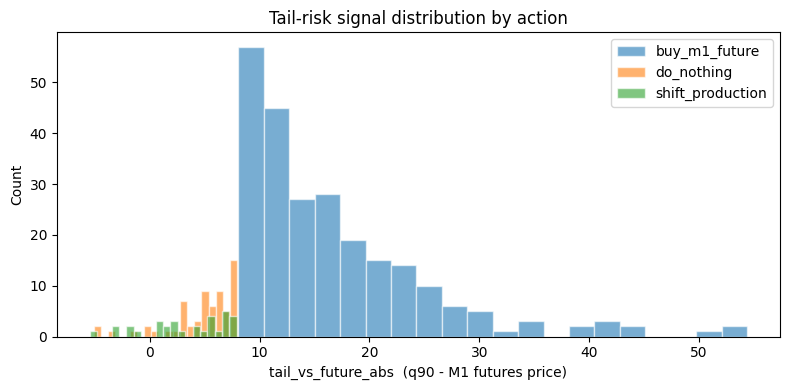

tail_vs_future_abs               tail_vs_central_abs  \
                                 mean median    max                mean   
recommended_action                                                        
buy_m1_future                   16.67  14.25  54.40               17.02   
do_nothing                       4.87   5.54   7.95               11.78   
shift_production                 3.34   4.29   7.89               24.17   

                                  
                   median    max  
recommended_action                
buy_m1_future       13.96  55.68  
do_nothing           9.22  37.36  
shift_production    22.90  36.12

In [6]:
import matplotlib.pyplot as plt

if 'tail_vs_future_abs' in heuristic_policy_df.columns:
    fig, ax = plt.subplots(figsize=(8, 4))
    for action, grp in heuristic_policy_df.groupby('recommended_action'):
        ax.hist(grp['tail_vs_future_abs'], bins=20, alpha=0.6, label=action, edgecolor='white')
    ax.set_title('Tail-risk signal distribution by action')
    ax.set_xlabel('tail_vs_future_abs  (q90 - M1 futures price)')
    ax.set_ylabel('Count')
    ax.legend()
    plt.tight_layout()
    plt.show()

context_stats = (
    heuristic_policy_df.groupby('recommended_action')[['tail_vs_future_abs', 'tail_vs_central_abs']]
    .agg(['mean', 'median', 'max'])
    .round(2)
)
display(context_stats)